# Assignment 11: Fine-Tuning GPT-2 on a Custom Text Style

**Objective:** To understand how fine-tuning can help a pretrained language model adapt to a specific writing style, by fine-tuning the small GPT-2 model on a custom text dataset and comparing its output with the original model.

## Step 1: Installing and Importing Libraries

In [1]:
!pip install transformers torch accelerate

In [2]:
import torch
import transformers
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("transformers version:", transformers.__version__)
print("Using device:", device)

transformers version: 5.18.0
Using device: cuda


## Step 2: Loading the Original GPT-2 and a Copy for Fine-Tuning

Two separate copies of the small GPT-2 model (124 million parameters) are loaded. The first one is the original model and will not be changed. The second one is the copy that will be fine-tuned. Keeping them separate lets us compare the outputs of the same prompt before and after fine-tuning.

In [3]:
# The tokenizer is the same as in Assignment 2
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Model 1: the original GPT-2 (this one will NOT be changed)
base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

# Model 2: a separate copy of GPT-2 (this one will be fine-tuned)
finetuned_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

# GPT-2 has no padding token, so the end-of-text token is used for padding
tokenizer.pad_token = tokenizer.eos_token
print("Padding token:", tokenizer.pad_token)

# Number of parameters in the model
total_parameters = sum(p.numel() for p in base_model.parameters())
print("Number of parameters:", total_parameters)

# Both copies should start with exactly the same weights
same_weights = torch.equal(base_model.transformer.wte.weight, finetuned_model.transformer.wte.weight)
print("Both models start with the same weights:", same_weights)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Padding token: <|endoftext|>
Number of parameters: 124439808
Both models start with the same weights: True


## Step 3: Generating Text from the Original GPT-2 (Before Fine-Tuning)

The two prompts from Assignment 2 are given to the original GPT-2: the main prompt used in all five experiments, and the story prompt used in the custom generations. Three samples are generated for each prompt, using the "balanced" settings from Assignment 2 (temperature 0.7, top_k 50, top_p 0.95, repetition penalty 1.2). The same function and settings will be used for the fine-tuned model later, so any difference in the output comes from the model and not from the settings.

In [4]:
# The two prompts used in Assignment 2
prompts = {
    "Main prompt": "The future of technology depends on the choices we make today.",
    "Story prompt": "She opened the old wooden door and found a letter that changed everything."
}

# A fixed seed for each sample, so the results can be repeated
seeds = [1, 2, 3]


def generate_text(model, prompt, seed):
    # 1. convert the prompt into tokens
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    # 2. fix the random seed so the same sample is produced every time
    torch.manual_seed(seed)

    # 3. generate new tokens (same settings as "Custom Generation 1" in Assignment 2)
    output = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id
    )

    # 4. convert the tokens back into text
    return tokenizer.decode(output[0], skip_special_tokens=True)

In [5]:
base_outputs = {}

for name, prompt in prompts.items():
    print("=" * 70)
    print(name, ":", prompt)

    for seed in seeds:
        text = generate_text(base_model, prompt, seed)
        base_outputs[(name, seed)] = text

        print(f"\n--- Base model, sample {seed} ---")
        print(text)

Main prompt : The future of technology depends on the choices we make today.

--- Base model, sample 1 ---
The future of technology depends on the choices we make today. But it may not be that easy for all those who are working to develop new technologies."
 (Reuters)
"Today, in many ways, what's happening is quite different from when I started my career," said Mr. Mearsheimer with a smile — and he wasn't exaggerating either

--- Base model, sample 2 ---
The future of technology depends on the choices we make today. We need to learn from what's happened, and if that means making more products tomorrow."
- The Guardian

--- Base model, sample 3 ---
The future of technology depends on the choices we make today.
"We are making a lot more than just cutting corners," he said. "Our industry is changing every day and it's important to see that change in how you use, store and access things."
Story prompt : She opened the old wooden door and found a letter that changed everything.

--- Base mo

## Step 4: Collecting the Dataset

The text used for fine-tuning is Shakespeare's dialogue. It is the "tiny Shakespeare" text file from the char-rnn repository on GitHub, a collection of dialogue from Shakespeare's plays. Shakespeare's text is in the public domain. The first 400 lines of the file are used as the original dataset. This text has a consistent writing style (older English vocabulary, verse lines and speaker names), which is very different from the modern news-like text GPT-2 generated in Step 3.

In [6]:
!wget -q -O shakespeare_raw.txt https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

In [7]:
# read the downloaded file as a list of lines
all_lines = open("shakespeare_raw.txt", encoding="utf-8").read().splitlines()
print("Lines in the full file:", len(all_lines))

# the first 400 lines are used as the original dataset
original_lines = all_lines[:400]

# save the original (uncleaned) dataset, because it has to be submitted
with open("original_dataset.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(original_lines))

print("Lines in the original dataset:", len(original_lines))
print()
print("First 15 lines of the original dataset:")
for number, line in enumerate(original_lines[:15], start=1):
    print(number, "|", line)

Lines in the full file: 40000
Lines in the original dataset: 400

First 15 lines of the original dataset:
1 | First Citizen:
2 | Before we proceed any further, hear me speak.
3 | 
4 | All:
5 | Speak, speak.
6 | 
7 | First Citizen:
8 | You are all resolved rather to die than to famish?
9 | 
10 | All:
11 | Resolved. resolved.
12 | 
13 | First Citizen:
14 | First, you know Caius Marcius is chief enemy to the people.
15 | 


## Step 5: Cleaning the Dataset

The original dataset contains blank lines and speaker names such as "First Citizen:". These are not part of the writing style, so they are removed (the speaker names are like usernames in a chat). Extra spaces at the start and end of each line are also removed. The raw file has no timestamps, so there is nothing of that kind to remove. The cleaned dataset is saved as a separate file and the original file is kept as it is.

In [8]:
clean_lines = []
removed_blank = 0
removed_labels = 0

for line in original_lines:
    line = line.strip()                    # remove extra spaces at the start and end

    if line == "":                         # blank line
        removed_blank += 1
        continue

    if line.endswith(":") and len(line.split()) <= 3:   # speaker name such as "First Citizen:"
        removed_labels += 1
        continue

    clean_lines.append(line)               # keep the line

# save the cleaned dataset in a separate file
with open("cleaned_dataset.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(clean_lines))

print("Lines in the original dataset:", len(original_lines))
print("Blank lines removed:", removed_blank)
print("Speaker names removed:", removed_labels)
print("Lines in the cleaned dataset:", len(clean_lines))

Lines in the original dataset: 400
Blank lines removed: 72
Speaker names removed: 73
Lines in the cleaned dataset: 255


In [9]:
# Check 1: average length of a line
words_per_line = [len(line.split()) for line in clean_lines]
print("Average words per line:", round(sum(words_per_line) / len(clean_lines), 1))

# Check 2: any digits or brackets left in the text?
leftover = [line for line in clean_lines if any(ch.isdigit() or ch in "[]()" for ch in line)]
print("Lines with digits or brackets:", len(leftover))

# Look at the cleaned dataset
print()
print("First 10 lines of the cleaned dataset:")
for number, line in enumerate(clean_lines[:10], start=1):
    print(number, "|", line)

Average words per line: 7.4
Lines with digits or brackets: 0

First 10 lines of the cleaned dataset:
1 | Before we proceed any further, hear me speak.
2 | Speak, speak.
3 | You are all resolved rather to die than to famish?
4 | Resolved. resolved.
5 | First, you know Caius Marcius is chief enemy to the people.
6 | We know't, we know't.
7 | Let us kill him, and we'll have corn at our own price.
8 | Is't a verdict?
9 | No more talking on't; let it be done: away, away!
10 | One word, good citizens.


## Step 6: Preparing the Training Data

GPT-2 cannot read text directly, so each cleaned line is converted into tokens (numbers). Each line becomes one training example. A small Dataset class holds these examples so the Trainer can use them.

In [10]:
class StyleDataset(Dataset):
    def __init__(self, lines, tokenizer, max_length=48):
        self.examples = []
        for line in lines:
            # convert the line into tokens (a line longer than max_length is cut)
            encoded = tokenizer(line, truncation=True, max_length=max_length)
            self.examples.append({
                "input_ids": encoded["input_ids"],
                "attention_mask": encoded["attention_mask"]
            })

    def __len__(self):
        # number of training examples
        return len(self.examples)

    def __getitem__(self, index):
        # the training example at this position
        return self.examples[index]


train_dataset = StyleDataset(clean_lines, tokenizer)
print("Number of training examples:", len(train_dataset))

Number of training examples: 255


In [11]:
# Look at one example
example = train_dataset[0]
print("Line:", clean_lines[0])
print("Token IDs:", example["input_ids"])
print("Tokens:", tokenizer.convert_ids_to_tokens(example["input_ids"]))
print("Decoded:", tokenizer.decode(example["input_ids"]))

# Length of every example in tokens
lengths = [len(item["input_ids"]) for item in train_dataset.examples]
print()
print("Shortest line (tokens):", min(lengths))
print("Longest line (tokens):", max(lengths))
print("Average (tokens):", round(sum(lengths) / len(lengths), 1))

Line: Before we proceed any further, hear me speak.
Token IDs: [8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13]
Tokens: ['Before', 'Ġwe', 'Ġproceed', 'Ġany', 'Ġfurther', ',', 'Ġhear', 'Ġme', 'Ġspeak', '.']
Decoded: Before we proceed any further, hear me speak.

Shortest line (tokens): 3
Longest line (tokens): 17
Average (tokens): 10.1


## Step 7: Setting Up the Trainer

Lines have different lengths, so a data collator pads the lines in each batch to the same length and creates the labels. The training settings are then put into TrainingArguments, and the Trainer is created with the fine-tuned copy of GPT-2, the training data and the collator. Training itself is done in the next step.

In [13]:
# The collator pads the lines in a batch and creates the labels
# mlm=False because GPT-2 predicts the next word (it is not a masked model like BERT)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Look at one batch of 4 lines after the collator has processed it
sample_batch = [train_dataset[i] for i in range(4)]
batch = data_collator(sample_batch)

print("input_ids shape:", batch["input_ids"].shape)
print("labels shape:", batch["labels"].shape)
print()
print("Example 1 input_ids:", batch["input_ids"][0].tolist())
print("Example 1 attention_mask:", batch["attention_mask"][0].tolist())
print("Example 1 labels:", batch["labels"][0].tolist())

input_ids shape: torch.Size([4, 12])
labels shape: torch.Size([4, 12])

Example 1 input_ids: [8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 50256, 50256]
Example 1 attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Example 1 labels: [8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, -100, -100]


In [14]:
training_args = TrainingArguments(
    output_dir="gpt2-finetuned",        # folder used by the Trainer
    num_train_epochs=5,                 # how many times the model sees the whole dataset
    per_device_train_batch_size=4,      # lines per training step
    learning_rate=5e-5,                 # size of each weight update
    weight_decay=0.01,                  # small penalty that keeps weights from growing too large
    logging_steps=10,                   # record the loss every 10 steps
    save_strategy="no",                 # we save the model ourselves after training
    report_to="none",                   # no online logging
    seed=42                             # same result every run
)

trainer = Trainer(
    model=finetuned_model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
    processing_class=tokenizer
)

batches_per_epoch = len(trainer.get_train_dataloader())
print("Batches per epoch:", batches_per_epoch)
print("Total training steps:", batches_per_epoch * training_args.num_train_epochs)

Batches per epoch: 64
Total training steps: 320


## Step 8: Training the Model

Now the fine-tuning is run. The Trainer goes through the 255 lines in batches, five times, and updates the weights of the GPT-2 copy each step. The loss is recorded every 10 steps and plotted. After training, the model is saved and a weight check confirms that only the fine-tuned model changed.

In [15]:
# Train the model (this is the actual fine-tuning)
train_result = trainer.train()

print()
print("Training time (seconds):", round(train_result.metrics["train_runtime"], 1))

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,4.990041
20,4.808902
30,4.737104
40,4.577451
50,4.473732
60,4.382875
70,4.185146
80,3.938708
90,3.874227
100,3.958293



Training time (seconds): 20.6


Loss values recorded: 32
First recorded loss (step 10 ): 4.99
Last recorded loss (step 320 ): 2.698


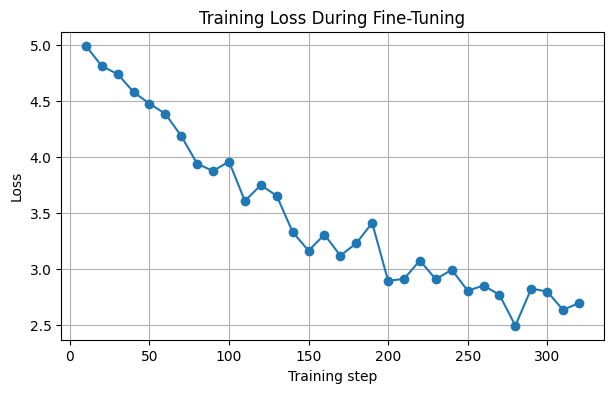

In [16]:
# Collect the loss values that the Trainer recorded
logged = [(entry["step"], entry["loss"]) for entry in trainer.state.log_history if "loss" in entry]
steps = [item[0] for item in logged]
losses = [item[1] for item in logged]

print("Loss values recorded:", len(losses))
print("First recorded loss (step", steps[0], "):", round(losses[0], 3))
print("Last recorded loss (step", steps[-1], "):", round(losses[-1], 3))

plt.figure(figsize=(7, 4))
plt.plot(steps, losses, marker="o")
plt.title("Training Loss During Fine-Tuning")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [17]:
import os

# Save the fine-tuned model and the tokenizer
trainer.save_model("gpt2-finetuned")
tokenizer.save_pretrained("gpt2-finetuned")
print("Files saved in gpt2-finetuned:", os.listdir("gpt2-finetuned"))

# Weight check: the base model should now be different from the fine-tuned model
base_wte = base_model.transformer.wte.weight
tuned_wte = finetuned_model.transformer.wte.weight

print()
print("Base and fine-tuned models have the same weights:", torch.equal(base_wte, tuned_wte))
print("Average weight change:", (base_wte - tuned_wte).abs().mean().item())

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Files saved in gpt2-finetuned: ['tokenizer.json', 'training_args.bin', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json']

Base and fine-tuned models have the same weights: False
Average weight change: 0.0011621888261288404


## Step 9: Generating Text with the Fine-Tuned Model

The fine-tuned model is now given the same two prompts as the base model, using the same generate_text function, the same settings and the same seeds (1, 2 and 3). Because everything else is identical, any difference in the output comes from the fine-tuning.

In [18]:
finetuned_model.eval()

finetuned_outputs = {}

for prompt_name, prompt in prompts.items():
    print("=====", prompt_name, "=====")
    print("Prompt:", prompt)

    for seed in seeds:
        text = generate_text(finetuned_model, prompt, seed)
        finetuned_outputs[(prompt_name, seed)] = text
        print()
        print("Seed", seed, ":")
        print(text)

    print()

===== Main prompt =====
Prompt: The future of technology depends on the choices we make today.

Seed 1 :
The future of technology depends on the choices we make today. The more you care about it, the greater your affection for us; and thus will they answer: that our countrymen are only like dogs to each other's crushes! What then? what now?! why go these proud men against one another with a smile--why not fight them off at once

Seed 2 :
The future of technology depends on the choices we make today. The first thing to do is devise means, and if you wish us good care our fathers well enough it may be that your services will bestow upon them; but for this purpose I know not where any country can find a more wholesome assembly than in Rome: though my friends tell me they feel

Seed 3 :
The future of technology depends on the choices we make today. For you, my friends--they say that they know not what to do; and as long ago their fathers were slaves in arms against Rome! What then? how wel

## Step 10: Before and After Comparison

The outputs of the base model (Step 3) and the fine-tuned model (Step 9) are shown side by side for every prompt and seed. After that, a few simple counts are made on the generated text. The counts are rough and are only meant to support what can be seen by reading the samples.

In [19]:
for prompt_name, prompt in prompts.items():
    print("=====", prompt_name, "=====")
    print("Prompt:", prompt)

    for seed in seeds:
        print()
        print("--- Seed", seed, "---")
        print("BASE MODEL:")
        print(base_outputs[(prompt_name, seed)])
        print()
        print("FINE-TUNED MODEL:")
        print(finetuned_outputs[(prompt_name, seed)])

    print()

===== Main prompt =====
Prompt: The future of technology depends on the choices we make today.

--- Seed 1 ---
BASE MODEL:
The future of technology depends on the choices we make today. But it may not be that easy for all those who are working to develop new technologies."
 (Reuters)
"Today, in many ways, what's happening is quite different from when I started my career," said Mr. Mearsheimer with a smile — and he wasn't exaggerating either

FINE-TUNED MODEL:
The future of technology depends on the choices we make today. The more you care about it, the greater your affection for us; and thus will they answer: that our countrymen are only like dogs to each other's crushes! What then? what now?! why go these proud men against one another with a smile--why not fight them off at once

--- Seed 2 ---
BASE MODEL:
The future of technology depends on the choices we make today. We need to learn from what's happened, and if that means making more products tomorrow."
- The Guardian

FINE-TUNED MO

In [21]:
import re

# Split text into lowercase words
def get_words(text):
    return [word.strip("'") for word in re.findall(r"[a-z']+", text.lower())]

# All words that appear in the cleaned training data
training_vocab = set()
for line in clean_lines:
    training_vocab.update(get_words(line))

# A small list of Older-English words
old_english_words = ["thee", "thou", "thy", "thine", "hath", "doth", "tis", "ere", "wherefore", "nay", "prithee"]

def count_style(outputs):
    total_words = 0
    in_vocab = 0
    questions = 0
    exclaims = 0
    dashes = 0
    old_english = 0

    for (prompt_name, seed), text in outputs.items():
        # only look at the new text, not the prompt that was given
        continuation = text[len(prompts[prompt_name]):]
        words = get_words(continuation)

        total_words += len(words)
        in_vocab += sum(1 for word in words if word in training_vocab)
        questions += continuation.count("?")
        exclaims += continuation.count("!")
        dashes += continuation.count("--")
        old_english += sum(1 for word in words if word in old_english_words)

    return {
        "Words generated (all 6 samples)": total_words,
        "Words found in training text (%)": round(100 * in_vocab / total_words, 1),
        "Question marks": questions,
        "Exclamation marks": exclaims,
        "Double dashes (--)": dashes,
        "Older-English words": old_english
    }

base_stats = count_style(base_outputs)
tuned_stats = count_style(finetuned_outputs)

print(f"{'Measure':<36}{'Base':>10}{'Fine-tuned':>14}")
for measure in base_stats:
    print(f"{measure:<36}{base_stats[measure]:>10}{tuned_stats[measure]:>14}")

Measure                                   Base    Fine-tuned
Words generated (all 6 samples)            245           302
Words found in training text (%)          62.0          95.7
Question marks                               0            12
Exclamation marks                            0             5
Double dashes (--)                           0             4
Older-English words                          0             3


## Style Differences Between the Base and Fine-Tuned Model

The fine-tuned model was trained on 255 cleaned lines taken from the beginning of the Tiny Shakespeare file. The same prompts, seeds and generation settings were used for both models, so the differences below come from the fine-tuning.

**1. Vocabulary and word forms**
The base model writes in modern English. Its samples use words such as "technologies", "industry", "school" and "teacher", and mention real places such as New York City, San Francisco and France. The fine-tuned model writes in older, Shakespeare-like English. Its samples contain forms such as "know not", "'Tis", "'tis true", "tell thee" and "answer'd". The share of generated words that also appear in the training text rose from 62.0% for the base model to 95.7% for the fine-tuned model.

**2. Sentence type and tone**
The base samples mostly make plain statements in the style of a news report or a story ("he said", "It read:"). The fine-tuned samples read like spoken speech. They ask questions, call out and address a group ("What then? what now?!", "why are you here?", "my friends", "our countrymen"). Across the six samples, the base model produced 0 question marks and 0 exclamation marks, and the fine-tuned model produced 12 question marks and 5 exclamation marks.

**3. Punctuation and layout**
The base samples use double quotation marks, line breaks and source lines such as "(Reuters)" and "- The Guardian". Each fine-tuned sample is a single block of text. They mostly use single quotation marks for speech, and they use semicolons and double dashes ("smile--why", "friends--they"). The double dash appeared 4 times in the fine-tuned samples and 0 times in the base samples. The missing line breaks are probably because every training example was a single line, but I have not tested this.

**4. Subject matter**
The base samples stay loosely near the prompts. The technology prompt leads to quotes about industry and change, and the letter prompt leads to the contents of a letter. The fine-tuned samples move away from the prompts to Rome, countrymen, fathers, grain and hunger, even though neither prompt mentions these.

## Conclusion

Fine-tuning GPT-2 on only 255 short lines changed its writing style clearly. The fine-tuned model imitates the older language, the questions and exclamations, and the punctuation of the dataset, while the base model keeps its general modern news-and-story style.

There are also limits. The fine-tuned text is less sensible than the base text, and it does not follow the topic of the prompts. All the training lines come from the opening part of one source, so the model learned that part's subject (Rome, citizens, grain) together with its style. The training loss fell from 4.99 to about 2.70, but it was measured only on the training lines. It shows that the data was learned, not that the generated text is better.

The comparison is based on only 6 samples, and the counts are rough. For example, the Older-English word list does not include forms such as "know not" or "answer'd", so the count of 3 is lower than what can be seen in the text. A larger and more varied dataset, and a separate test set, would give a more reliable result.